In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load data
orders = pd.read_csv('orders.csv')
customers = pd.read_csv('customers.csv')
products = pd.read_csv('products.csv')
returns = pd.read_csv('returns.csv')

# Convert dates
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Merge datasets
df = orders.merge(customers, on='customer_id', how='left') \
           .merge(products, on='product_id', how='left') \
           .merge(returns, on='order_id', how='left')

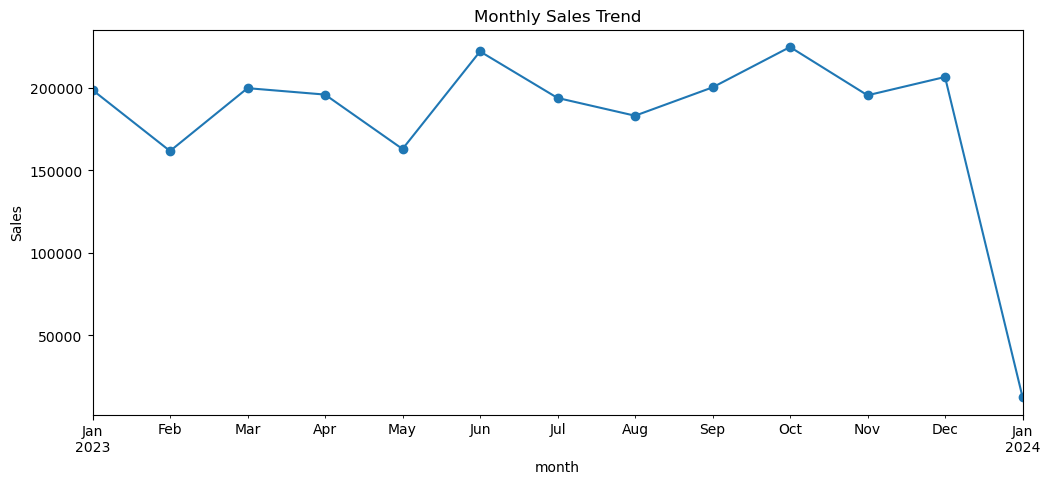

In [5]:
# Monthly Sales Trend
df['month'] = df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('month')['sales'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.show()


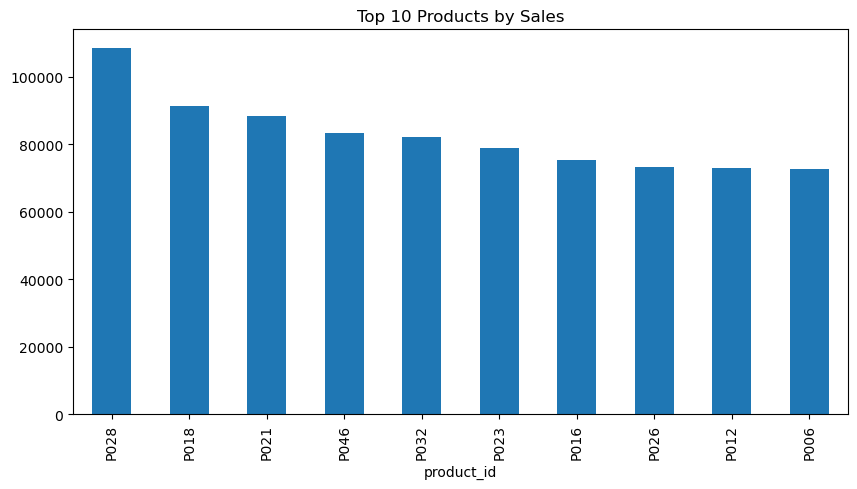

In [6]:
# Top 10 Products
top_products = df.groupby('product_id')['sales'].sum().nlargest(10)
top_products.plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Products by Sales')
plt.show()


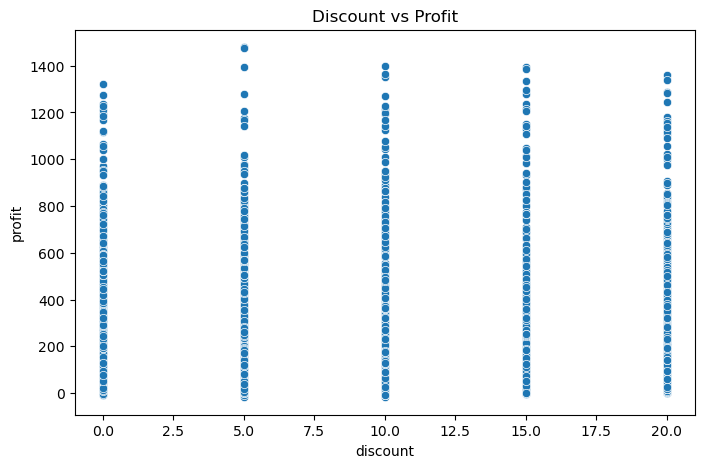

In [7]:
# Discount vs Profit
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='discount', y='profit')
plt.title('Discount vs Profit')
plt.show()


In [8]:
# RFM Analysis
rfm = df.groupby('customer_id').agg({
    'order_date': lambda x: (df['order_date'].max() - x.max()).days,
    'order_id': 'count',
    'sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
C0001,20,6,5567.60
C0002,17,9,10085.93
C0003,71,5,5522.59
C0004,2,7,7431.72
C0005,27,9,13238.44
